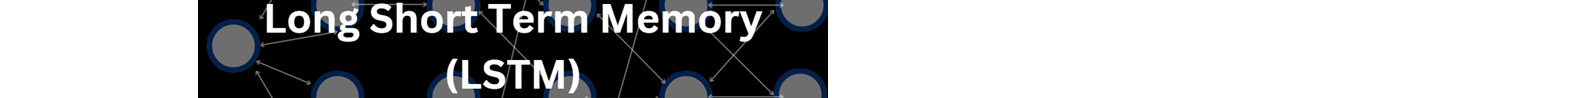

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('../../DataSets/weatherAUS.csv', encoding='utf-8', usecols=['Date', 'Location', 'MinTemp', 'MaxTemp'])

In [4]:
#Drop records where target MinTemp=NaN or MaxTemp=NaN
df = df.dropna(subset=['MinTemp', 'MaxTemp'])

In [5]:
# Convert dates to year-months
df['Year-Month']= (pd.to_datetime(df['Date'], yearfirst=True)).dt.strftime('%Y-%m')

In [6]:
# Derive median daily temperature (mid point between Daily Max and Daily Min)
df['MedTemp']=df[['MinTemp', 'MaxTemp']].median(axis=1)

In [7]:
df

,Date,Location,MinTemp,MaxTemp,Year-Month,MedTemp
0,2008-12-01,Albury,13.4,22.9,2008-12,18.15
1,2008-12-02,Albury,7.4,25.1,2008-12,16.25
2,2008-12-03,Albury,12.9,25.7,2008-12,19.30
3,2008-12-04,Albury,9.2,28.0,2008-12,18.60
4,2008-12-05,Albury,17.5,32.3,2008-12,24.90
...,...,...,...,...,...,...
145454,2017-06-20,Uluru,3.5,21.8,2017-06,12.65
145455,2017-06-21,Uluru,2.8,23.4,2017-06,13.10
145456,2017-06-22,Uluru,3.6,25.3,2017-06,14.45
145457,2017-06-23,Uluru,5.4,26.9,2017-06,16.15


## Aggregate to monthly averages

In [8]:
# Create a copy of an original dataframe
df2=df[['Location', 'Year-Month', 'MedTemp']].copy()

In [9]:
# Calculate monthly average temperature for each location
df2 = df2.groupby(['Location', 'Year-Month'], as_index=False)['MedTemp'].mean()

In [10]:
# Transpose dataframe 
# Pivot to wide format
df2_pivot = df2.pivot(index='Location', columns='Year-Month', values='MedTemp')

In [11]:
df2_pivot

Year-Month,2007-11,2007-12,2008-01,2008-02,2008-03,2008-04,2008-05,2008-06,2008-07,2008-08,...,2016-09,2016-10,2016-11,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06
Location,,,,,,,,,,,,,,,,,,,,,
Adelaide,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.091935,10.646774,...,13.241667,15.790323,18.413333,22.025806,24.417742,22.844643,23.337097,18.335000,14.290323,11.339583
Albany,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.466667,14.232759,16.489286,17.482000,18.256250,18.914000,19.002083,17.250000,15.806897,14.805556
Albury,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.213333,13.617742,18.170000,22.677419,25.298387,23.239286,23.067742,15.516667,11.417742,7.972000
AliceSprings,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.258333,21.330645,26.291667,28.016129,29.453226,28.676786,28.132258,20.423333,16.474194,10.864583
BadgerysCreek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,14.766667,17.037097,21.485000,25.065385,26.430645,25.107143,22.050000,17.205000,14.372581,12.766000
Ballarat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.426667,10.600000,13.428333,17.345161,19.833871,17.835714,19.145161,13.046667,9.427419,7.102000
Bendigo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.011667,12.595161,16.818333,21.022581,23.114516,21.066071,22.262903,15.251667,11.029630,8.054000
Brisbane,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.501613,15.274194,...,20.031667,21.098387,24.770000,25.604839,27.188333,27.561111,26.332759,21.363793,19.945161,17.710000
Cairns,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,25.045000,25.574194,27.360000,27.882258,28.412903,28.205357,28.387097,25.845000,24.448387,22.376000


In [12]:
# Remove locations with excessive missing values (NaN)
df2_pivot = df2_pivot.drop(
    ['Dartmoor', 'Katherine', 'Melbourne', 'Nhil', 'Uluru'],
    axis=0, errors='ignore'
)

In [13]:
# Remove months with lots of missing data (NaN) 
df2_pivot=df2_pivot.drop(['2007-11', '2007-12', '2008-01', '2008-02', '2008-03', '2008-04', '2008-05', '2008-06', '2008-07', '2008-08', '2008-09', '2008-10', '2008-11', '2008-12', '2017-01', '2017-02', '2017-03', '2017-04', '2017-05', '2017-06'], axis=1)

In [14]:
df2_pivot

Year-Month,2009-01,2009-02,2009-03,2009-04,2009-05,2009-06,2009-07,2009-08,2009-09,2009-10,...,2016-03,2016-04,2016-05,2016-06,2016-07,2016-08,2016-09,2016-10,2016-11,2016-12
Location,,,,,,,,,,,,,,,,,,,,,
Adelaide,24.967742,25.057143,20.685484,17.908333,14.324194,12.540000,12.388710,13.832258,15.026667,16.708065,...,22.730645,18.708333,16.091935,12.466667,11.696774,12.696774,13.241667,15.790323,18.413333,22.025806
Albany,19.861667,20.150000,18.433871,17.461667,15.417742,13.321667,12.920968,12.988710,12.568333,15.329032,...,19.660345,17.583333,14.827419,13.235000,12.891667,12.590476,12.466667,14.232759,16.489286,17.482000
Albury,25.485484,25.439286,20.535484,15.410000,11.716129,9.206667,8.201613,9.932258,11.951786,14.595161,...,23.290323,17.580000,13.069355,9.500000,9.517742,9.625806,12.213333,13.617742,18.170000,22.677419
AliceSprings,29.240323,28.642857,27.470968,21.181667,14.437097,13.580000,12.933871,19.232258,22.040000,22.020968,...,27.695161,22.403333,18.280645,14.571667,12.816129,14.424194,17.258333,21.330645,26.291667,28.016129
BadgerysCreek,24.467742,22.948214,20.877419,17.305000,14.312903,11.769643,10.727419,12.520968,15.558333,16.646429,...,22.938710,19.743333,15.164516,12.613333,12.053226,11.940323,14.766667,17.037097,21.485000,25.065385
Ballarat,19.498387,19.605357,16.440323,12.175000,10.222581,7.768333,7.108065,8.366129,9.555000,11.288710,...,18.667742,14.500000,11.006452,7.238333,7.224194,7.943548,9.426667,10.600000,13.428333,17.345161
Bendigo,22.995161,22.932143,18.941935,14.511667,12.095161,8.640000,7.837097,9.635484,10.696667,13.859677,...,22.119355,16.440000,12.324194,8.596667,9.111290,9.154839,11.011667,12.595161,16.818333,21.022581
Brisbane,25.720000,25.707143,24.550000,22.611667,19.003226,16.458333,15.783871,18.780645,20.180000,21.729032,...,25.325806,23.663333,21.012903,17.328333,17.361290,17.419355,20.031667,21.098387,24.770000,25.604839
Cairns,27.488710,27.721429,27.400000,26.173333,23.477419,22.780000,21.837097,22.920968,24.815000,25.024194,...,27.882258,26.685000,25.620968,23.741667,23.029032,22.383871,25.045000,25.574194,27.360000,27.882258


In [15]:
# Remove months with insufficient data
months_to_drop = [
    '2007-11','2007-12',
    '2008-01','2008-02','2008-03','2008-04','2008-05','2008-06',
    '2008-07','2008-08','2008-09','2008-10','2008-11','2008-12',
    '2017-01','2017-02','2017-03','2017-04','2017-05','2017-06'
]
df2_pivot = df2_pivot.drop(months_to_drop, axis=1, errors='ignore')

In [16]:
# Add missing months 2011-04, 2011-04, 2011-04 and impute data
df2_pivot['2011-04']=(df2_pivot['2011-03']+df2_pivot['2011-05'])/2
df2_pivot['2012-12']=(df2_pivot['2012-11']+df2_pivot['2013-01'])/2
df2_pivot['2013-02']=(df2_pivot['2013-01']+df2_pivot['2013-03'])/2

In [17]:
# Sort columns so Year-Months are in the correct order
df2_pivot=df2_pivot.reindex(sorted(df2_pivot.columns), axis=1)

In [18]:
import plotly.graph_objects as go

In [19]:
# Plot average monthly temperature derived from daily medians for each location
fig = go.Figure()
for location in df2_pivot.index:
    fig.add_trace(go.Scatter(x=df2_pivot.loc[location, :].index, 
                             y=df2_pivot.loc[location, :].values,
                             mode='lines', name=location,
                             opacity=0.8, line=dict(width=1)
                            ))

In [20]:
# Change chart background color
fig.update_layout(dict(plot_bgcolor = 'white'), showlegend=True)

# Update axes lines
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey', 
                 zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey', 
                 showline=True, linewidth=1, linecolor='black',
                 title='Date'
                )

fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey', 
                 zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey', 
                 showline=True, linewidth=1, linecolor='black',
                 title='Degrees Celsius'
                )

# Set figure title
fig.update_layout(title=dict(text="Average Monthly Temperatures", font=dict(color='black')))

fig.show()

In [21]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler # for feature scaling

In [22]:
def shaping(datain, timestep, scaler):

    # Convert input dataframe to array and flatten
    arr = datain.to_numpy().flatten()
    
    # Scale 
    arr=scaler.fit_transform(arr.reshape(-1, 1)).flatten()

    X_list, y_list = [], []
    for i in range(len(datain.columns) - 2 * timestep + 1):
        X_list.append(arr[i:i+timestep])
        y_list.append(arr[i+timestep:i+2*timestep])

    # Reshape input and target arrays
    X_out = np.array(X_list).reshape(-1, timestep, 1)
    y_out = np.array(y_list).reshape(-1, timestep, 1)
    return X_out, y_out

In [23]:
##### Step 1 - Specify parameters
timestep=18
location='Canberra'
scaler = MinMaxScaler(feature_range=(-1, 1))

In [24]:
##### Step 2 - Prepare data

# Split data into train and test dataframes
df_train=df2_pivot.iloc[:, :-2*timestep].copy()
df_test=df2_pivot.iloc[:, -2*timestep:].copy()

In [25]:
# Select one location
dfloc_train = df_train[df_train.index==location].copy()
dfloc_test = df_test[df_test.index==location].copy()

In [26]:
# Use previously defined shaping function to reshape the data for LSTM
X_train, y_train = shaping(datain=dfloc_train, timestep=timestep, scaler=scaler)
X_test, y_test = shaping(datain=dfloc_test, timestep=timestep, scaler=scaler)

In [27]:
from tensorflow import keras # for building Neural Networks
from keras.models import Sequential # for creating a linear stack of layers for our Neural Network
from keras import Input # for instantiating a keras tensor
from keras.layers import Bidirectional, LSTM, RepeatVector, Dense, TimeDistributed # for creating layers inside the Neural Network

In [28]:
##### Step 3 - Specify the structure of a Neural Network
model = Sequential(name="LSTM-Model")
# Input Layer - need to speicfy the shape of inputs
model.add(Input(shape=(X_train.shape[1],X_train.shape[2]), name='Input-Layer'))
# Encoder Layer
model.add(Bidirectional(LSTM(units=32, activation='tanh', recurrent_activation='sigmoid', stateful=False), name='Hidden-LSTM-Encoder-Layer'))
# Repeat Vector
model.add(RepeatVector(y_train.shape[1], name='Repeat-Vector-Layer'))
# Decoder Layer
model.add(Bidirectional(LSTM(units=32, activation='tanh', recurrent_activation='sigmoid', stateful=False, return_sequences=True), name='Hidden-LSTM-Decoder-Layer'))
# Output Layer, Linear(x) = x
model.add(TimeDistributed(Dense(units=1, activation='linear'), name='Output-Layer'))


In [29]:
##### Step 4 - Compile the model
model.compile(
    optimizer='adam', loss='mean_squared_error',
    metrics=['mean_squared_error', 'mean_absolute_error']
)

In [30]:
history = model.fit(X_train, y_train,
    batch_size=1, epochs=100,
    validation_split=0.2, shuffle=True, verbose=0
)

In [31]:
##### Step 6 - Use model to make predictions
# Predict results on training data
pred_train = model.predict(X_train)
# Predict esults on test data
pred_test = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 838ms/step


In [32]:
##### Step 7 - Print Performance Summary
print("")
print('-------------------- Model Summary --------------------')
model.summary() # print model summary
print("")
print('-------------------- Weights and Biases --------------------')
print("Too many parameters to print but you can use the code provided if needed")
print("")
for layer in model.layers:
    print(layer.name)
    for item in layer.get_weights():
        print("  ", item)
print("")


-------------------- Model Summary --------------------


Model: "LSTM-Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden-LSTM-Encoder-Layer       │ (None, 64)             │         8,704 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Repeat-Vector-Layer             │ (None, 18, 64)         │             0 │
│ (RepeatVector)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-LSTM-Decoder-Layer       │ (None, 18, 64)         │        24,832 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output-Layer (TimeDistributed)  │ (None, 18, 1)          │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,805 (393.77 KB)

 Trainable params: 33,601 (131.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 67,204 (262.52 KB)


-------------------- Weights and Biases --------------------
Too many parameters to print but you can use the code provided if needed

Hidden-LSTM-Encoder-Layer
   [[-0.16366893 -0.16050403  0.03527437 -0.19258262 -0.08579428  0.11297745
   0.1795864  -0.00414014 -0.06292925  0.18242155  0.07682994  0.14792241
  -0.20070729  0.00168706  0.12934358  0.15695736  0.1955236  -0.13019152
  -0.03162789 -0.0682797  -0.18460369 -0.18154803 -0.09816702  0.19004738
  -0.09614706  0.19324869  0.14634866 -0.04096006 -0.20455578 -0.20634478
  -0.08676889 -0.00364069 -0.1128016   0.2393487  -0.10339954 -0.27144635
   0.01759828 -0.01964412 -0.0041231  -0.10008439  0.04255226  0.19485101
   0.03108025 -0.23143978 -0.18211843 -0.16950068  0.00426546 -0.06248548
  -0.04107331  0.15662326 -0.0703451  -0.00404041  0.08378788 -0.00284096
  -0.05432896 -0.06372063  0.1851608  -0.10493054 -0.21708451  0.04317903
  -0.01472056 -0.19144589 -0.14707994 -0.10567632  0.21355407 -0.17122227
   0.08568781 -0.0020

In [33]:
# Print the last value in the evaluation metrics contained within history file
print('-------------------- Evaluation on Training Data --------------------')
for item in history.history:
    print("Final", item, ":", history.history[item][-1])
print("")

-------------------- Evaluation on Training Data --------------------
Final loss : 0.007909925654530525
Final mean_absolute_error : 0.07052517682313919
Final mean_squared_error : 0.007909925654530525
Final val_loss : 0.039931125938892365
Final val_mean_absolute_error : 0.16260980069637299
Final val_mean_squared_error : 0.039931125938892365



In [34]:
# Evaluate the model on the test data using "evaluate"
print('-------------------- Evaluation on Test Data --------------------')
results = model.evaluate(X_test, y_test)
print("")

-------------------- Evaluation on Test Data --------------------


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 934ms/step - loss: 0.0793 - mean_absolute_error: 0.2360 - mean_squared_error: 0.0793



In [35]:
# Plot average monthly temperatures (actual and predicted) for test (out of time) data
fig = go.Figure()

# Trace for actual temperatures
fig.add_trace(go.Scatter(x=np.array(dfloc_test.columns),
                         y=np.array(dfloc_test.values).flatten(),
                         mode='lines',
                         name='Average Monthly Temperatures - Actual (Test)',
                         opacity=0.8,
                         line=dict(color='black', width=1)
                        ))

# Trace for predicted temperatures
fig.add_trace(go.Scatter(x=np.array(dfloc_test.columns[-timestep:]),
                         y=scaler.inverse_transform(pred_test.reshape(-1,1)).flatten(),
                         mode='lines',
                         name='Average Monthly Temperatures - Predicted (Test)',
                         opacity=0.8,
                         line=dict(color='red', width=1)
                        ))

# Change chart background color
fig.update_layout(dict(plot_bgcolor = 'white'))

# Update axes lines
fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey', 
                 zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey', 
                 showline=True, linewidth=1, linecolor='black',
                 title='Year-Month'
                )

fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey', 
                 zeroline=True, zerolinewidth=1, zerolinecolor='lightgrey', 
                 showline=True, linewidth=1, linecolor='black',
                 title='Degrees Celsius'
                )

# Set figure title
fig.update_layout(title=dict(text="Average Monthly Temperatures", font=dict(color='black')),
                  legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
                 )

fig.show()